![](https://mcd.unison.mx/wp-content/themes/awaken/img/logo_mcd.png)

# Ejemplo de regularización con regresión logística

## Aprendizaje Automático Aplicado

## Maestría en Ciencia de Datos

**Angel Barraza**, 2025

[Abrir en google Colab](https://colab.research.google.com/drive/1WvYJpUARBxUnnsnK_KWlXiM8WCxlHgXq?usp=sharing)

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement


plt.rcParams['figure.figsize'] = (10,5)
plt.style.use('ggplot')

## 1. Algunas funciones útiles

Esto, antes de agregarle la regularización

In [ ]:
def medias_std(x):
    """
    Obtiene un vector de medias y desviaciones estandar para normalizar

    """
    return np.mean(x, axis=0), np.std(x, axis=0)

def normaliza(x, mu, des_std):
    """
    Normaliza los datos x

    """
    return (x - mu) / des_std

def map_poly(grad, x):
    """
    Encuentra las características polinomiales hasta el grado grad de la matriz de datos x, asumiendo que x[:n, 0] es la expansión de orden 1 (los valores de cada atributo)

    """
    if int(grad) < 2:
        raise ValueError('grad debe de ser mayor a 1')

    M, n = x.shape
    atrib = x.copy()
    x_phi = x.copy()
    for i in range(2, int(grad) + 1):
        for comb in combinations_with_replacement(range(n), i):
            x_phi = np.c_[x_phi, np.prod(atrib[:, comb], axis=1)]
    return x_phi

def logistica(z):
    """
    Calcula la función logística para cada elemento de z

    """
    return 1 / (1 + np.exp(-z))

def error_in(x, y, w, b):
    """
    Calcula el error en muestra para la regresión logística

    """
    a = logistica(x @ w + b)
    return -np.nansum(
            np.sum(np.log(a[y > 0.5])) +
            np.sum(np.log(1 - a[y < 0.5]))
        ) / a.shape[0]

def gradiente_error(x, y, w, b):
    """
    Calcula el gradiente de la función de error en muestra.

    """
    M = x.shape[0]
    error = y - logistica(x @ w + b)
    dw = -x.T @ error / M
    db = - error.mean()
    return dw, db

def dg(x, y, w, b, alpha, max_iter=10_000, tol=1e-6, historial=False):
    """
    Descenso de gradiente por lotes

    """
    M, n = x.shape
    hist = [error_in(x, y, w, b)] if historial else None
    for epoch in range(1, max_iter):
        dw, db = gradiente_error(x, y, w, b)
        w -= alpha * dw
        b -= alpha * db
        error = error_in(x, y, w, b)
        if historial:
            hist.append(error)
        if np.abs(np.max(dw)) < tol:
            break
    return w, b, hist

def predictor(x, w, b):
    """
    Predice la clase de cada elemento de x

    """
    return np.where(x @ w + b > 0, 1, 0)

def plot_separacion2D(x, y, w, b, mu, sigma, grado, titulo):
    xx, yy = np.meshgrid(np.linspace(x[:, 0].min(), x[:, 0].max(), 100),
                         np.linspace(x[:, 1].min(), x[:, 1].max(), 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_poly = map_poly(grado, grid)
    grid_poly = (grid_poly - mu) / sigma

    zz = grid_poly @ w + b
    zz = zz.reshape(xx.shape)
    plt.contourf(xx, yy, zz, levels=[-1000, 0, 1000], alpha=0.2, colors=['blue', 'red'])
    plt.scatter(x[y == 1, 0], x[y == 1, 1], c='r', label='Cumple calidad')
    plt.scatter(x[y == 0, 0], x[y == 0, 1], c='b', label='Rechazado')
    plt.title(titulo)
    plt.xlabel('1')
    plt.ylabel('2')
    plt.legend()


## 2. Regularización

Tomemos una base de datos que si bien es sintética es representativa de una familia de problemas a resolver. Supongamos que estámos opimizando la fase de pruebas dentro de la linea de producción de la empresa Microprocesadores del Noroeste S.A. de C.V.. La idea es reducir el banco de pruebas de cada nuevo microprocesador fabricado y en lugar de hacer 50 pruebas, reducirlas a 2. En el conjunto de datos tenemos los valores que obtuvo cada componente en las dos pruebas seleccionadas, y la decisión que se tomo con cada dispositivo (esta desición se tomo con el banco de 50 reglas). Los datos los podemos visualizar a continuación.

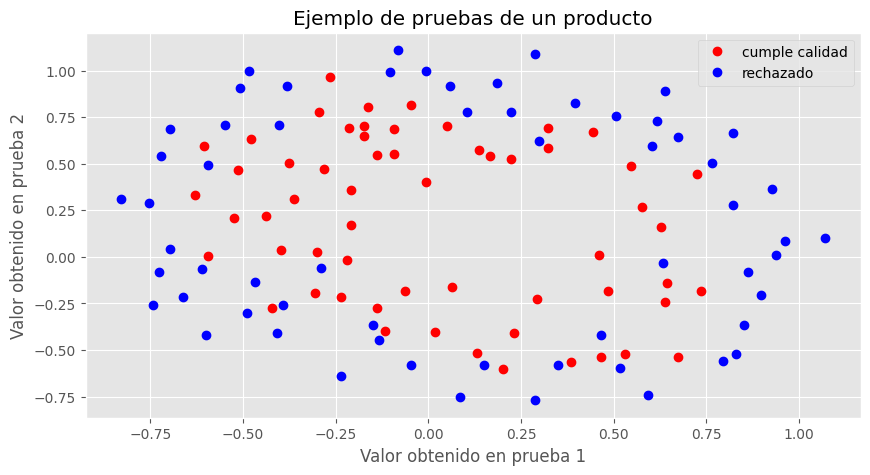

In [ ]:
url = "https://github.com/mcd-unison/aaa-curso/raw/main/ejemplos/prod_test.csv"
datos = np.loadtxt(url, comments='%', delimiter=',')

x, y = datos[:,0:-1], datos[:,-1]

plt.plot(x[y == 1, 0], x[y == 1, 1], 'or', label='cumple calidad')
plt.plot(x[y == 0, 0], x[y == 0, 1], 'ob', label='rechazado')
plt.title(u'Ejemplo de pruebas de un producto')
plt.xlabel(u'Valor obtenido en prueba 1')
plt.ylabel(u'Valor obtenido en prueba 2')
plt.legend(loc=0)

Cláramente este problema no se puede solucionar con un clasificador lineal (1 orden), por lo que hay que probar otros tipos de clasificadores.

**Completa el código para hacer regresión polinomial para polinomios de orden 2, 4, 6 y 8, y muestra los resultados en una figura. Recuerda que este ejercicio puede tomar bastante tiempo de cómputo. Posiblemente tengas que hacer ajustes en el código para manejar diferentes valores de alpha y max_iter de acuerdo a cada caso**

<Figure size 1200x1200 with 0 Axes>

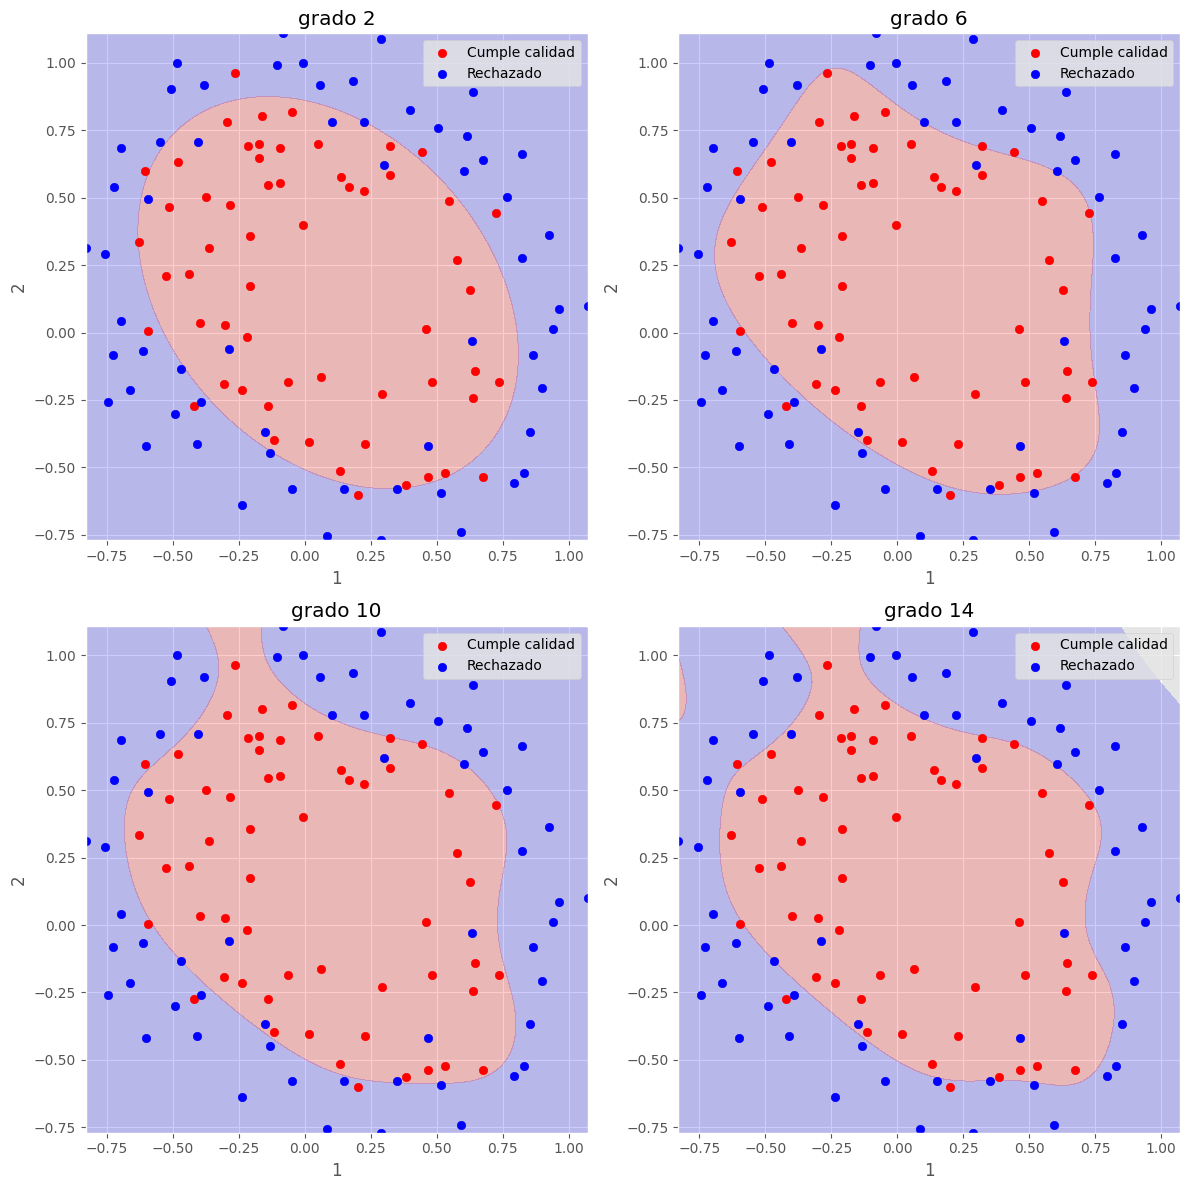

In [ ]:
# Entrenamiento para diferentes grados polinomiales
grado_polinomios = [2, 6, 10, 14]
plt.figure(figsize=(12, 12))

# Entrenamiento para diferentes grados polinomiales
grado_polinomios = [2, 6, 10, 14]
plt.figure(figsize=(12, 12))

for i, grado in enumerate(grado_polinomios):
    x_poly = map_poly(grado, x)

    # Normalización
    mu, sigma = medias_std(x_poly)
    x_poly = normaliza(x_poly, mu, sigma)

    # Inicialización de parámetros
    w = np.zeros(x_poly.shape[1])
    b = 0

    # Entrenamiento con descenso de gradiente
    w, b, _ = dg(x_poly, y, w, b, alpha=0.1, max_iter=10_000, tol=1e-6)

    # Visualización con mu y sigma correctos
    plt.subplot(2, 2, i + 1)
    plot_separacion2D(x, y, w, b, mu, sigma, grado, f'grado {grado}')

plt.tight_layout()
plt.show()


Como podemos ver del ejercicio anterior, es dificil determinar el grado del polinomio, y en algunos casos es demasiado general (subaprendizaje) y en otros demasiado específico (sobreaprendizaje).

¿Que podría ser la solución?, Una solución posible es utilizar un polinomio de alto grado (o relativamente alto), y utilizar la **regularización** para controlar la generalización del algoritmo, a través de una variable $\lambda$.

Recordemos, la función de costos de la regresión logística con regularización es:

$$
costo(w, b) = E_{in}(w, b) + \frac{\lambda}{M} regu(w),
$$

donde $regu(w)$ es una función de regularización, la cual puede ser $l_1$, $l_2$ u otras, tal como vimos en clase.

**Completa el siguiente código, utilizando una regularización en $L_2$**


In [ ]:
def costo(x, y, w, b, lambd):
    M = x.shape[0]
    a = logistica(x @ w + b)
    reg_term = (lambd / (2 * M)) * np.sum(w ** 2)
    return (-np.sum(y * np.log(a) + (1 - y) * np.log(1 - a)) / M) + reg_term

def grad_regu(x, y, w, b, lambd):
    M = x.shape[0]
    error = y - logistica(x @ w + b)
    dw = -x.T @ error / M + (lambd / M) * w
    db = - error.mean()
    return dw, db

def dg_regu(x, y, w, b, alpha, lambd, max_iter=10_000, tol=1e-4, historial=False):
    M, n = x.shape
    hist = [costo(x, y, w, b, lambd)] if historial else None
    for epoch in range(1, max_iter):
        dw, db = grad_regu(x, y, w, b, lambd)
        w -= alpha * dw
        b -= alpha * db
        error = costo(x, y, w, b, lambd)
        if historial:
            hist.append(error)
        if np.abs(np.max(dw)) < tol:
            break
    return w, b, hist


**Desarrolla las funciones y scripts necesarios para realizar la regresión logística con un polinomio de grado `grado` y con cuatro valores de regularización diferentes. Grafica la superficie de separación para cuatro valores diferentes de $\lambda$.**

Realiza varias pruebas para encontrar cual es la relación de `grado` y de $\lambda$ que sea un buen compromiso entre generalizar demasiado o tener sobreaprendizaje.

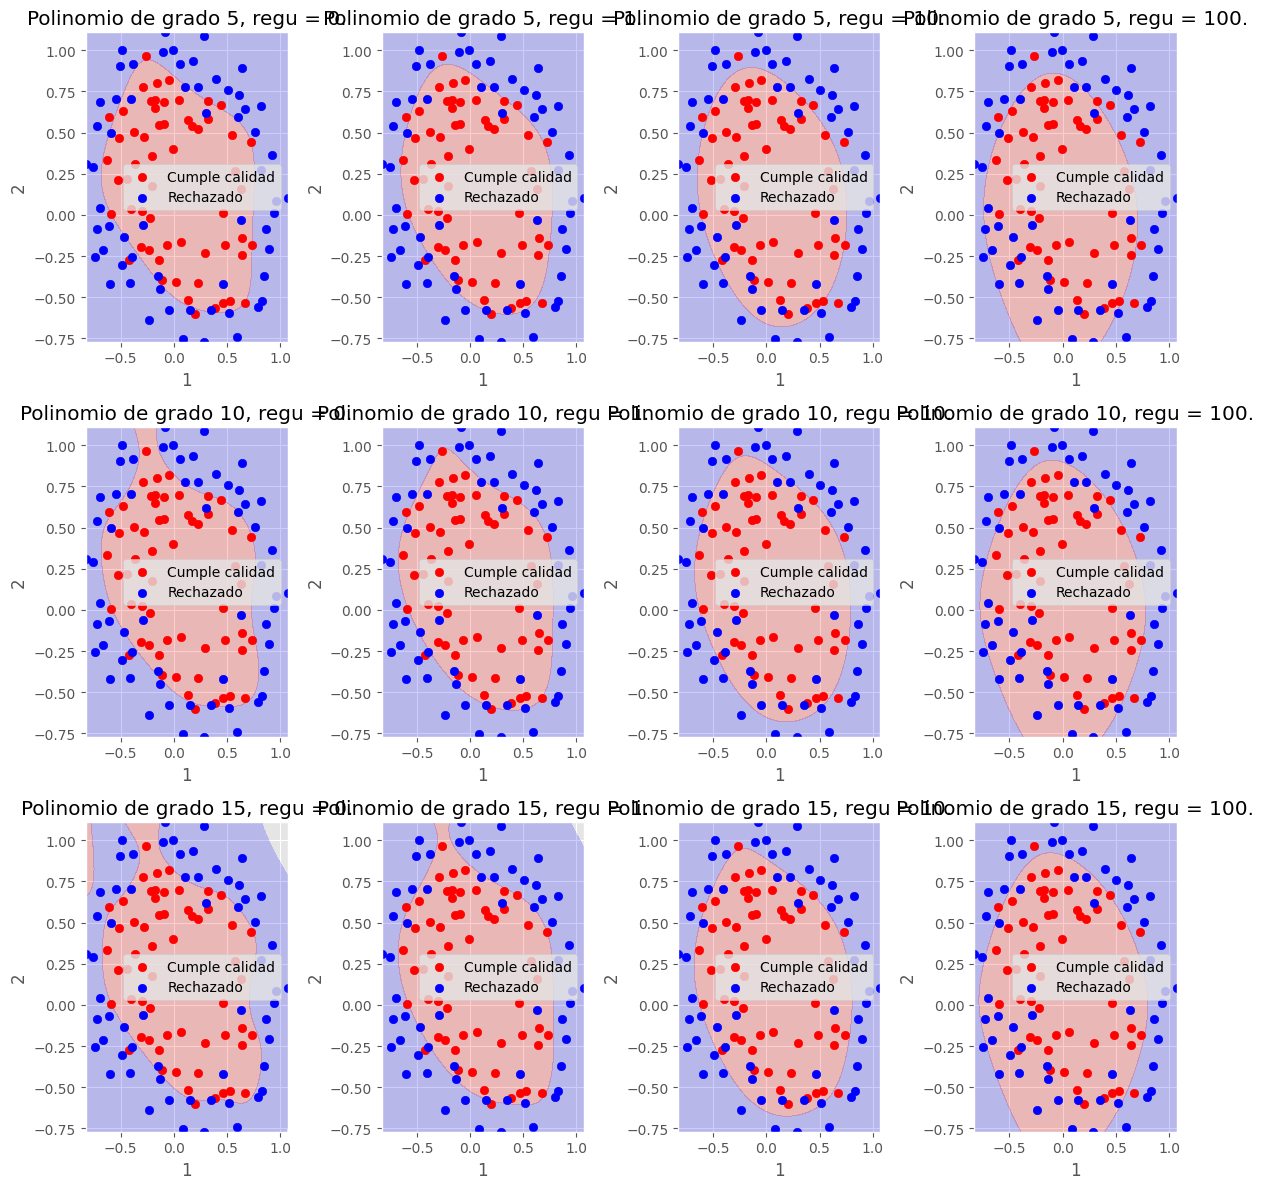

In [ ]:
grados = [5, 10, 15]
valores_lambda = [0, 1, 10, 100]
plt.figure(figsize=(12, 12))

for grado in grados:
    for i, lambd in enumerate(valores_lambda):
        phi_x = map_poly(grado, x)
        mu, sigma = medias_std(phi_x)
        phi_x_norm = normaliza(phi_x, mu, sigma)

        w = np.zeros(phi_x_norm.shape[1])
        b = 0
        w, b, _ = dg_regu(phi_x_norm, y, w, b, alpha=0.1, lambd=lambd, max_iter=10_000, tol=1e-6)

        plt.subplot(len(grados), len(valores_lambda), grados.index(grado) * len(valores_lambda) + i + 1)
        plot_separacion2D(x, y, w, b, mu, sigma, grado, f'Polinomio de grado {grado}, regu = {lambd}.')

plt.tight_layout()
plt.show()

Es muy importante el análisis y las conclusiones que puedas sacar de este ejercicio.

**Escribe aquí tus conclusiones**

- Un grado alto sin regularización lleva a sobreajuste, mientras que una regularización excesiva en cualquier grado puede llevar a subajuste.

- No hay un solo conjunto de valores de grado, alphas y 𝜆 que funcionen para todos los problemas. Es importante realizar pruebas con diferentes combinaciones para encontrar el mejor resultado y para ver comportamientos.

- Evaluar los resultados con métricas puede proporcionar una visión más cuantitativa del desempeño del modelo.

- La inspección visual de la superficie de decisión es crucial para detectar patrones de sobreajuste o subajuste. Si la frontera es demasiado complicada y cambia bruscamente, probablemente haya sobreajuste, y si la frontera es demasiado simple y no separa bien las clases, el modelo está subajustando.